This is a synthetic single-cell RNA sequencing (scRNA-seq) dataset designed to simulate the complex biological environment of a solid tumor. The primary inspiration is the difficulty of obtaining clean, annotated, and privacy-compliant single-cell data for educational and benchmark purposes.

The dataset models the Tumor Microenvironment (TME), which is critical in cancer progression and immunotherapy response. It allows users to practice core scRNA-seq analysis tasks, including cell type identification, differential gene expression analysis, and discovering potential therapeutic targets.

Core Analytical Challenges Users can leverage this dataset for several key challenges:

Cell Type Classification: Build machine learning models to classify single cells based on their gene expression profiles into one of three distinct types (Cancer, T_Cell, Fibroblast).

Biomarker Discovery: Identify which genes (e.g., Gene_A, Gene_B) are the most powerful predictors for a given cell type or disease state.

Visualization and Dimensionality Reduction: Apply techniques like PCA or UMAP to confirm the biological separation of the defined cell types.

Source Information The data is entirely synthetic and was generated using a log-normal distribution model to mimic the sparsity and variability inherent in real scRNA-seq count data. This ensures the data is clean, lacks real-world bias, and is perfectly suitable for benchmarking machine learning algorithms.

**1. Cell Type Classification**

In [3]:
#!pip install umap-learn

In [4]:
##-----Importing Libraries-----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import umap

In [11]:
##-----Loading Dataset-----
data = pd.read_csv("Task 4_Gene_Expression_Analysis_and_Disease_Relationship_Synthetic.csv")
data.head()

,Cell_ID,Cell_Type,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
0,C0001,T_Cell,Tumor,5.565866,4.546474,10.532535,2.113285,0.951138,9.580415,7.818137
1,C0002,T_Cell,Tumor,5.351163,3.840752,10.642705,4.361618,0.952454,10.540695,8.298277
2,C0003,T_Cell,Tumor,4.935363,2.271616,10.389736,2.839926,1.906194,8.416975,7.158779
3,C0004,Cancer,Tumor,4.095084,14.881377,3.268237,3.204284,9.922546,7.357785,0.016234
4,C0005,Fibroblast,Tumor,4.669715,5.444694,2.561298,14.046708,3.126553,3.372407,11.646391


In [13]:
data.shape, data.columns

((3000, 10),
 Index(['Cell_ID', 'Cell_Type', 'Disease_Status', 'Gene_E_Housekeeping',
        'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy',
        'Pathway_Score_Inflam', 'UMAP_1'],
       dtype='object'))


 Data Description:        Gene_E_Housekeeping  Gene_A_Oncogene  Gene_B_Immune  Gene_C_Stromal  \
count          3000.000000      3000.000000    3000.000000     3000.000000   
mean              5.002702         7.319094       5.982890        6.852504   
std               0.495695         4.959009       4.383173        4.861748   
min               3.436678         1.087581       1.015551        1.176086   
25%               4.658408         3.286695       2.525109        3.011726   
50%               4.979579         4.773690       3.517219        4.144346   
75%               5.326971        12.947793      11.269680       12.645769   
max               7.165827        21.508750      16.901272       19.199503   

       Gene_D_Therapy  Pathway_Score_Inflam       UMAP_1  
count     3000.000000           3000.000000  3000.000000  
mean         4.952360              7.043063     6.516869  
std          3.692807              3.424917     3.970911  
min          0.500000              1.0000

C:\Users\koush\AppData\Local\Temp\ipykernel_17068\1073789406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cell_Type', data=data, palette = 'viridis')


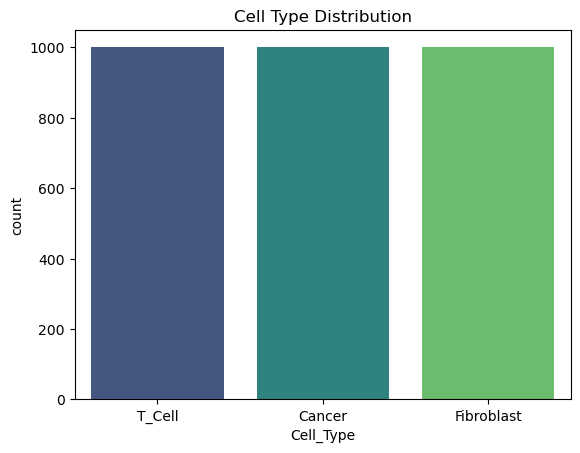

In [15]:
##-----EDA-----
print("\n Data Description:", data.describe())
print("\n Nan values:", data.isnull().sum())
      
print("\n Cell Types:", data['Cell_Type'].value_counts())
sns.countplot(x='Cell_Type', data=data, palette = 'viridis')
plt.title("Cell Type Distribution")
plt.show()


In [17]:
##-----Encoding categorical variables-----
le_cell = LabelEncoder()
le_disease = LabelEncoder()

data['Cell_Type_Encoded'] = le_cell.fit_transform(data['Cell_Type'])
data['Disease_Status_Encoded'] = le_disease.fit_transform(data['Disease_Status'])

In [19]:
data.columns

Index(['Cell_ID', 'Cell_Type', 'Disease_Status', 'Gene_E_Housekeeping',
       'Gene_A_Oncogene', 'Gene_B_Immune', 'Gene_C_Stromal', 'Gene_D_Therapy',
       'Pathway_Score_Inflam', 'UMAP_1', 'Cell_Type_Encoded',
       'Disease_Status_Encoded'],
      dtype='object')

In [21]:
##-----Feature and Target-----
X = data.drop(columns=['Cell_ID', 'Cell_Type','Disease_Status','UMAP_1', 'Cell_Type_Encoded'])
y = data['Cell_Type_Encoded']

In [23]:
##-----Scaling-----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**1a. Visualization**

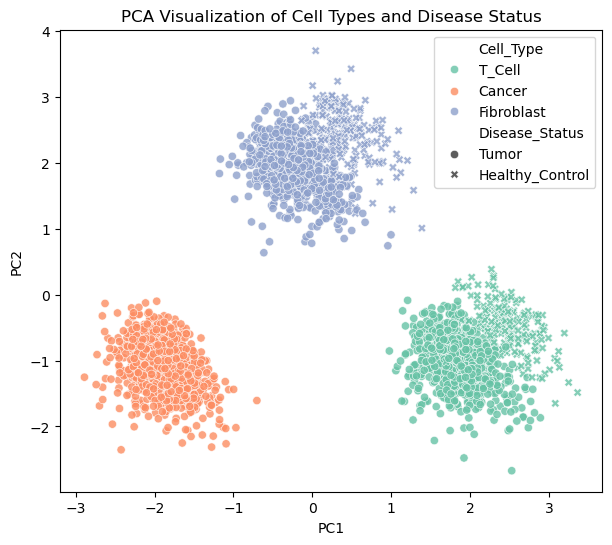

In [26]:
##-----PCA Visualization-----
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data['PC1'], data['PC2'] = pca_result[:,0], pca_result[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Cell_Type', style='Disease_Status', palette='Set2', alpha=0.8)
plt.title('PCA Visualization of Cell Types and Disease Status')
plt.show()

C:\Users\koush\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


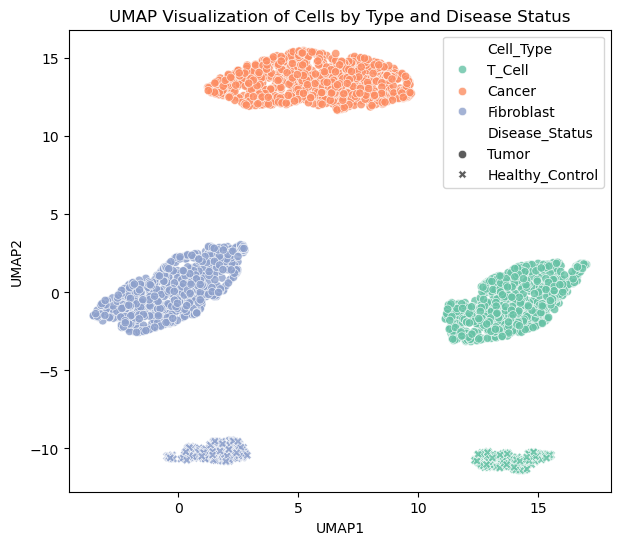

In [28]:
##-----UMAP (Uniform Manifold Approximation and Projection)-----
reducer = umap.UMAP(n_neighbors=10, min_dist=0.2, random_state=88)
umap_result = reducer.fit_transform(X_scaled)
data['UMAP1'], data['UMAP2'] = umap_result[:,0], umap_result[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=data, x='UMAP1', y='UMAP2', hue='Cell_Type', style='Disease_Status', palette='Set2', alpha=0.8)
plt.title('UMAP Visualization of Cells by Type and Disease Status')
plt.show()


 Classification Report :
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00       200
  Fibroblast       1.00      1.00      1.00       200
      T_Cell       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



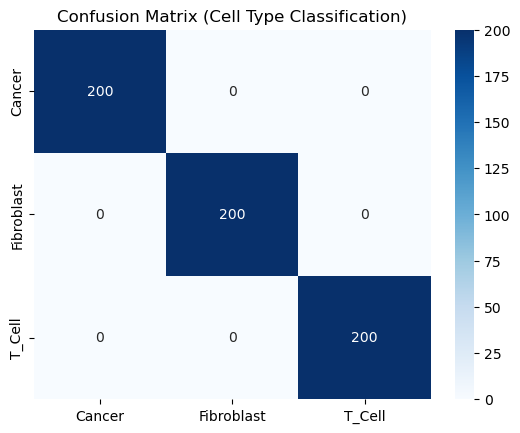

In [30]:
##-----Model : Random Forest Classifier-----
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=88)

rf = RandomForestClassifier(n_estimators=200, random_state=88)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n Classification Report :")
print(classification_report(y_test, y_pred, target_names=le_cell.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_cell.classes_, yticklabels=le_cell.classes_)
plt.title("Confusion Matrix (Cell Type Classification)")
plt.show()

**2. Biomarker Discovery**

C:\Users\koush\AppData\Local\Temp\ipykernel_17068\1840890758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette='viridis')


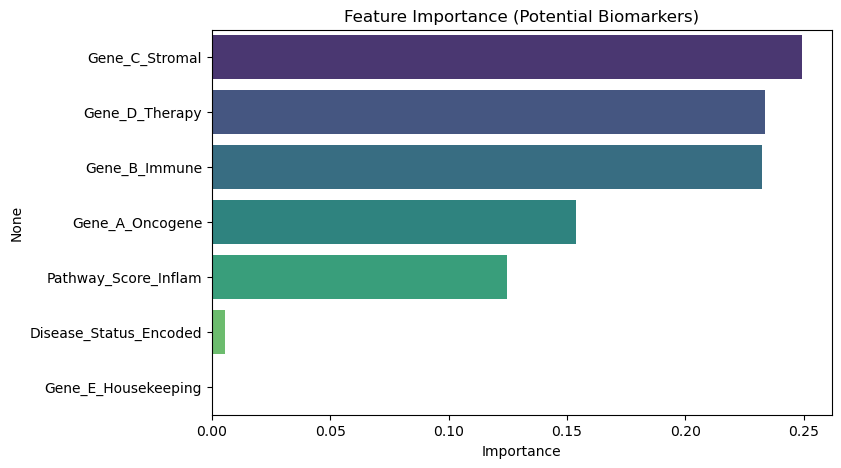


 Ranked Gene Importance:
Gene_C_Stromal            0.249462
Gene_D_Therapy            0.233826
Gene_B_Immune             0.232367
Gene_A_Oncogene           0.153837
Pathway_Score_Inflam      0.124728
Disease_Status_Encoded    0.005350
Gene_E_Housekeeping       0.000430
dtype: float64


In [33]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_genes = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=top_genes.values, y=top_genes.index, palette='viridis')
plt.title('Feature Importance (Potential Biomarkers)')
plt.xlabel('Importance')
plt.show()

print("\n Ranked Gene Importance:")
print(top_genes)

C:\Users\koush\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\koush\AppData\Local\Temp\ipykernel_17068\2617999194.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='-log10(p)', y='Gene', data=dge_results, palette='viridis')


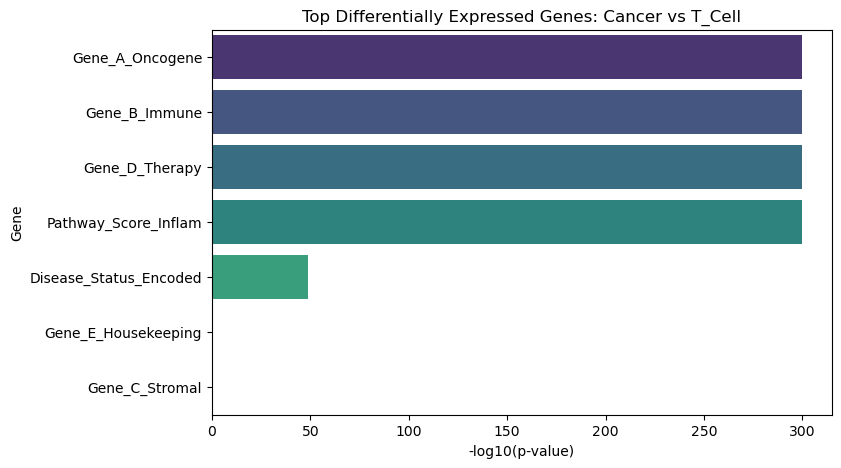


Top Differentially Expressed Genes:
                     Gene        p_value
1         Gene_A_Oncogene  1.000000e-300
2           Gene_B_Immune  1.000000e-300
4          Gene_D_Therapy  1.000000e-300
5    Pathway_Score_Inflam  1.000000e-300
6  Disease_Status_Encoded   1.440388e-49
0     Gene_E_Housekeeping   7.792952e-01
3          Gene_C_Stromal   7.925035e-01


In [35]:
##------Statistical Differential Expression-----
if set(['Cancer', 'T_Cell']).issubset(data['Cell_Type'].unique()):
    group1 = data[data['Cell_Type'] == 'Cancer'][X.columns]
    group2 = data[data['Cell_Type'] == 'T_Cell'][X.columns]

    pvals = []
    for gene in X.columns:
        # Perform independent t-test for each gene
        _, p = stats.ttest_ind(group1[gene], group2[gene], equal_var=False, nan_policy='omit')
        pvals.append(p)

    # Create results dataframe
    dge_results = pd.DataFrame({
        'Gene': X.columns,
        'p_value': pvals
    })

    # Handle potential numerical issues
    dge_results['p_value'] = dge_results['p_value'].replace(0, 1e-300)
    dge_results['-log10(p)'] = -np.log10(dge_results['p_value'])

    # Top 20 genes (most significant)
    dge_results = dge_results.sort_values('p_value').head(20)

    # Plot
    plt.figure(figsize=(8,5))
    sns.barplot(x='-log10(p)', y='Gene', data=dge_results, palette='viridis')
    plt.title('Top Differentially Expressed Genes: Cancer vs T_Cell')
    plt.xlabel('-log10(p-value)')
    plt.ylabel('Gene')
    plt.show()

    print("\nTop Differentially Expressed Genes:")
    print(dge_results[['Gene', 'p_value']])
else:
    print("Either 'Cancer' or 'T_Cell' cell type not found in data['Cell_Type']")